<a href="https://colab.research.google.com/github/PriyankaDevaprasad/Forest-Cover-Type-Classification/blob/main/Forest_Cover_type.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **🌲 Forest Cover Type Classification Using Machine Learning**


**Multiclass Classification | Environmental & Geographic Data**

## **Project Introduction**

Forest ecosystems are influenced by several environmental and geographical
factors such as elevation, slope, aspect, soil type, distance to water,
and terrain characteristics.

In this project, machine learning techniques are used to predict the
forest cover type of a geographical location based on cartographic and
environmental features.

The project follows an end-to-end machine learning workflow, including
data exploration, data preprocessing, feature engineering, handling class
imbalance, model development, model evaluation, hyperparameter tuning,
and deployment.

## **Problem Statement**

The objective of this project is to predict the forest cover type of a
given geographical location using cartographic and environmental
features.

The dataset contains information related to elevation, aspect, slope,
distances to hydrology, roadways and fire points, hillshade values,
wilderness areas, and soil types.

The target variable, `Cover_Type`, represents the forest cover class.

This is a multiclass classification problem because the target variable
contains multiple forest cover categories.

## **Project Objective**

The main objectives of this project are:

- Understand the structure and characteristics of the dataset.
- Perform exploratory data analysis to identify important patterns.
- Handle missing values, duplicates, and data quality issues.
- Engineer meaningful features from the available variables.
- Handle class imbalance appropriately.
- Train and compare multiple machine learning classification models.
- Evaluate models using appropriate classification metrics.
- Perform cross-validation and hyperparameter tuning.

## **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import pickle

##**Loading dataset**

In [2]:
f=pd.read_csv('cover_type.csv')

## **Data Understanding**

In [3]:
print(f.shape)

(145890, 13)


In [4]:
f.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [5]:
f.describe().T


,count,mean,std,min,25%,50%,75%,max
Elevation,145890.0,2874.458949,210.801279,1863.0,2747.0,2909.0,3004.0,3849.0
Aspect,145890.0,141.127418,107.719296,0.0,54.0,108.0,217.0,360.0
Slope,145890.0,11.925574,6.319326,0.0,7.0,11.0,15.0,61.0
Horizontal_Distance_To_Hydrology,145890.0,251.824738,192.473899,0.0,95.0,212.0,362.0,1343.0
Vertical_Distance_To_Hydrology,145890.0,34.554322,41.215776,-146.0,7.0,23.0,51.0,554.0
Horizontal_Distance_To_Roadways,145890.0,3313.827541,1687.779953,0.0,1848.0,3420.0,4673.0,7117.0
Hillshade_9am,145890.0,217.368106,21.590298,0.0,207.0,222.0,232.0,254.0
Hillshade_Noon,145890.0,224.874748,16.084851,99.0,216.0,226.0,236.0,254.0
Hillshade_3pm,145890.0,139.788203,31.311690,0.0,121.0,140.0,159.0,248.0
Horizontal_Distance_To_Fire_Points,145890.0,3044.958105,1761.882341,0.0,1608.0,2713.0,4478.0,7173.0


In [6]:
f.head()


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


**Checking Duplicates**

In [7]:
print(f.duplicated().sum())

0


No duplicates in the dataset

**Checking missing values**

In [8]:
print(f.isnull().sum())

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64


No missing values in the dataset

**Checking Target Variable**

In [9]:
f["Cover_Type"].value_counts().sort_index()

,count
Cover_Type,
Aspen,3069
Cottonwood/Willow,2160
Douglas-fir,2160
Krummholz,2160
Lodgepole Pine,103071
Ponderosa Pine,2160
Spruce/Fir,31110


**Detecting Outliers**

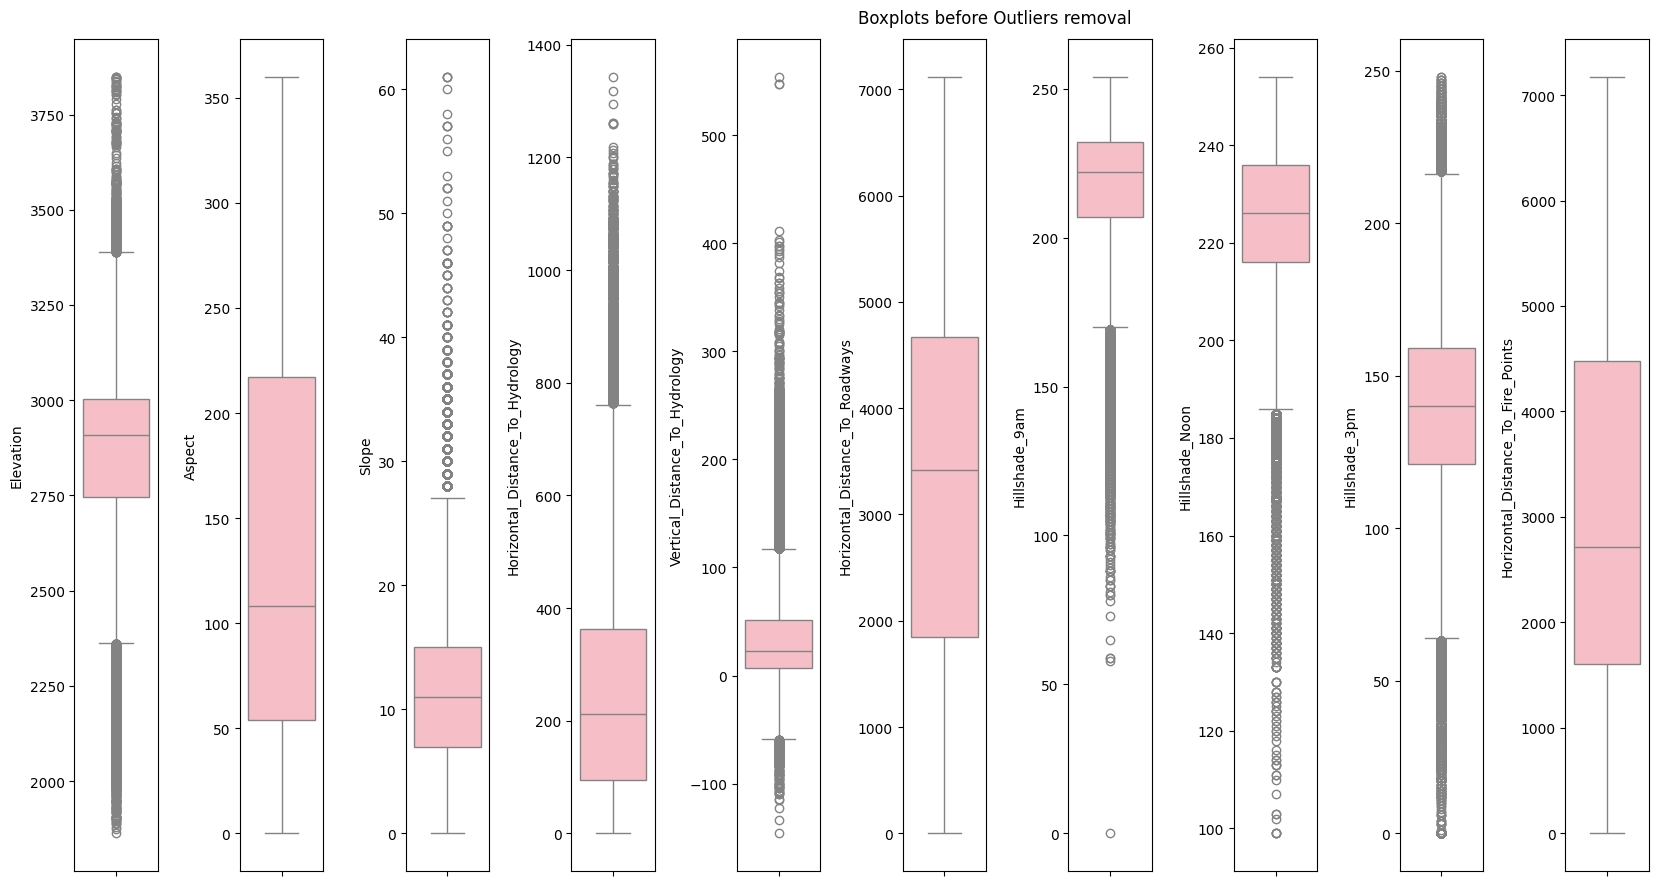

In [11]:
f_box=f.copy()
num_cols=f_box.drop(['Cover_Type','Wilderness_Area','Soil_Type'],axis=1)
num_cols=num_cols.columns
f_box=f_box.reset_index(drop=True)
plt.figure(figsize=(20, 9))
plt.suptitle("Boxplots before Outliers removal")
for i in range(0, len(num_cols)):
    plt.subplot(1, 12, i+1)
    sns.boxplot(y=f[num_cols[i]],color='lightpink')
    plt.tight_layout()

In [73]:
f[(f['Elevation']>3300)]

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Aspect_Group,Elevation_Slope,Distance_To_Hydrology,Mean_Hillshade
1434,3305,205,2.079442,430,1.694137,5167,-0.266331,1.528678,166,1206,4,1,29,2,23135,443.846820,209.333333
1447,3331,358,2.772589,361,0.693913,3635,-1.135127,-0.956374,152,2014,6,1,38,1,49965,366.117467,186.333333
1480,3335,52,2.708050,240,0.138198,4207,0.298394,-1.111571,112,1302,6,1,29,0,46690,242.684981,182.000000
1504,3375,61,2.639057,150,-1.123753,4142,0.552347,-0.902873,112,1195,6,1,38,0,43875,150.119952,184.666667
1643,3301,219,1.945910,402,1.194877,3337,-0.417550,1.528678,169,1969,6,1,29,2,19806,410.888063,209.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14843,3358,126,2.397895,212,-0.026754,849,1.112868,0.446483,125,4080,4,2,32,0,33580,213.974298,198.666667
14844,3337,60,2.890372,90,-1.069906,2419,0.618499,-1.399036,99,4153,6,2,35,0,56729,90.138782,177.333333
14846,3336,199,2.944439,658,3.210782,1167,-0.513990,2.201872,170,4307,4,2,33,2,60048,685.160565,211.333333
14855,3308,23,2.639057,309,-0.324856,1694,-0.466200,-0.848469,135,4943,6,2,22,1,43004,309.467284,186.666667


In [13]:
f[f['Vertical_Distance_To_Hydrology']>450]

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
1803,2931,283,26,778,554,854,138,230,227,2642,Lodgepole Pine,3,33
1892,2922,272,31,799,547,875,123,231,238,2136,Lodgepole Pine,3,28
11938,2924,272,32,816,547,886,122,231,238,2554,Lodgepole Pine,3,33


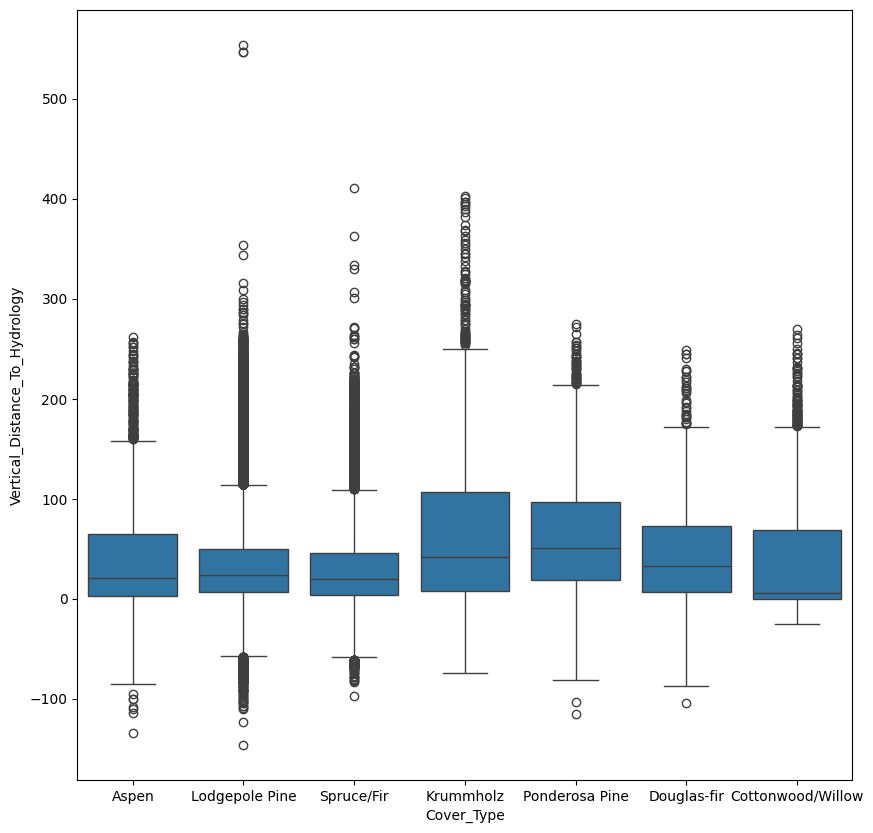

In [14]:
plt.figure(figsize=(10,10))
sns.boxplot(x="Cover_Type",y="Vertical_Distance_To_Hydrology",data=f)
plt.show()

In [15]:
f[f["Cover_Type"] == "Lodgepole Pine"]["Vertical_Distance_To_Hydrology"].describe()

,Vertical_Distance_To_Hydrology
count,103071.000000
mean,33.735066
std,38.262651
min,-146.000000
25%,7.000000
50%,24.000000
75%,50.000000
max,554.000000


In [16]:
f = f[f['Vertical_Distance_To_Hydrology'] <= 500].copy()

f.reset_index(drop=True, inplace=True)

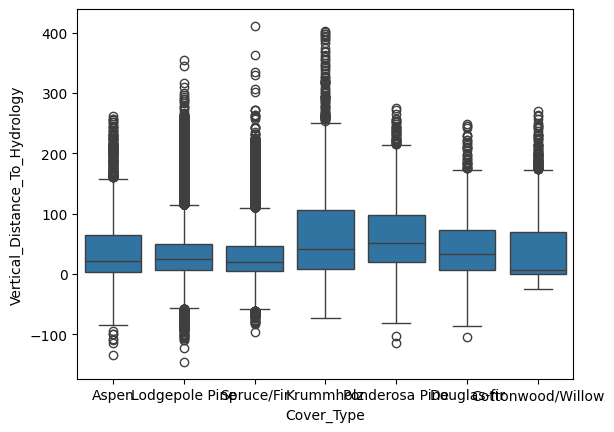

In [17]:
sns.boxplot(x="Cover_Type",y="Vertical_Distance_To_Hydrology",data=f)
plt.show()

In [18]:
f[f['Hillshade_9am']<70]

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
2239,2618,301,52,124,59,1789,0,157,231,1396,Douglas-fir,3,13
2720,2113,310,46,270,91,268,59,162,218,90,Ponderosa Pine,4,10
2789,2032,303,44,153,136,182,65,175,228,175,Ponderosa Pine,4,10
4927,2367,314,47,228,143,1273,59,155,210,962,Ponderosa Pine,4,10
12806,2281,310,46,108,91,1401,58,162,218,1073,Ponderosa Pine,4,10


In [19]:
f=f[f['Hillshade_9am']>100].copy()

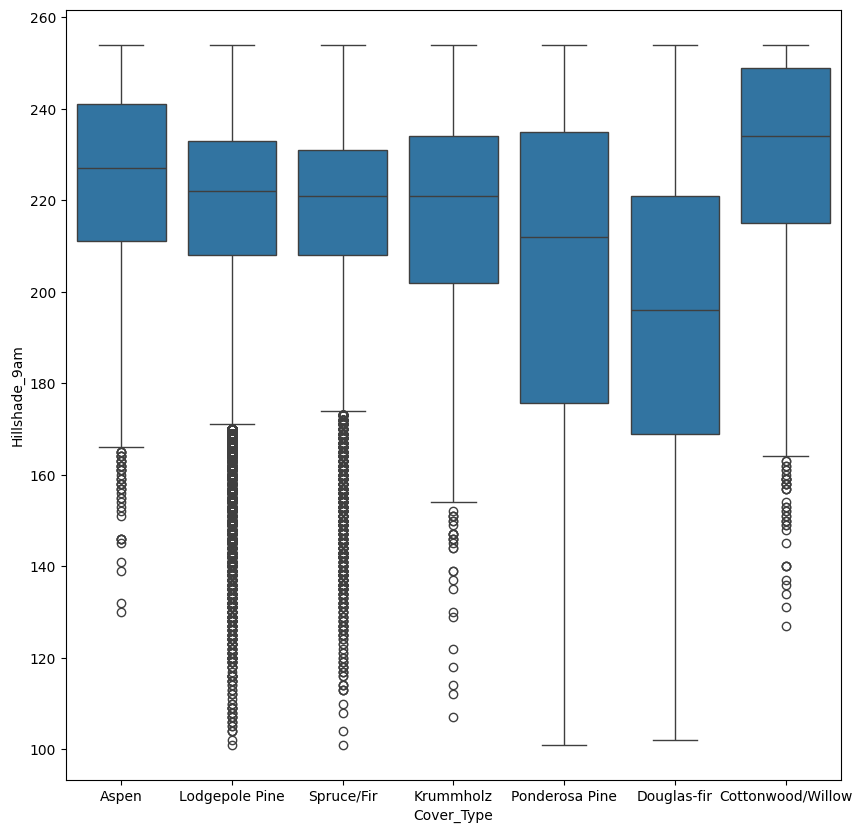

In [20]:
plt.figure(figsize=(10,10))
sns.boxplot(x="Cover_Type",y="Hillshade_9am",data=f)
plt.show()

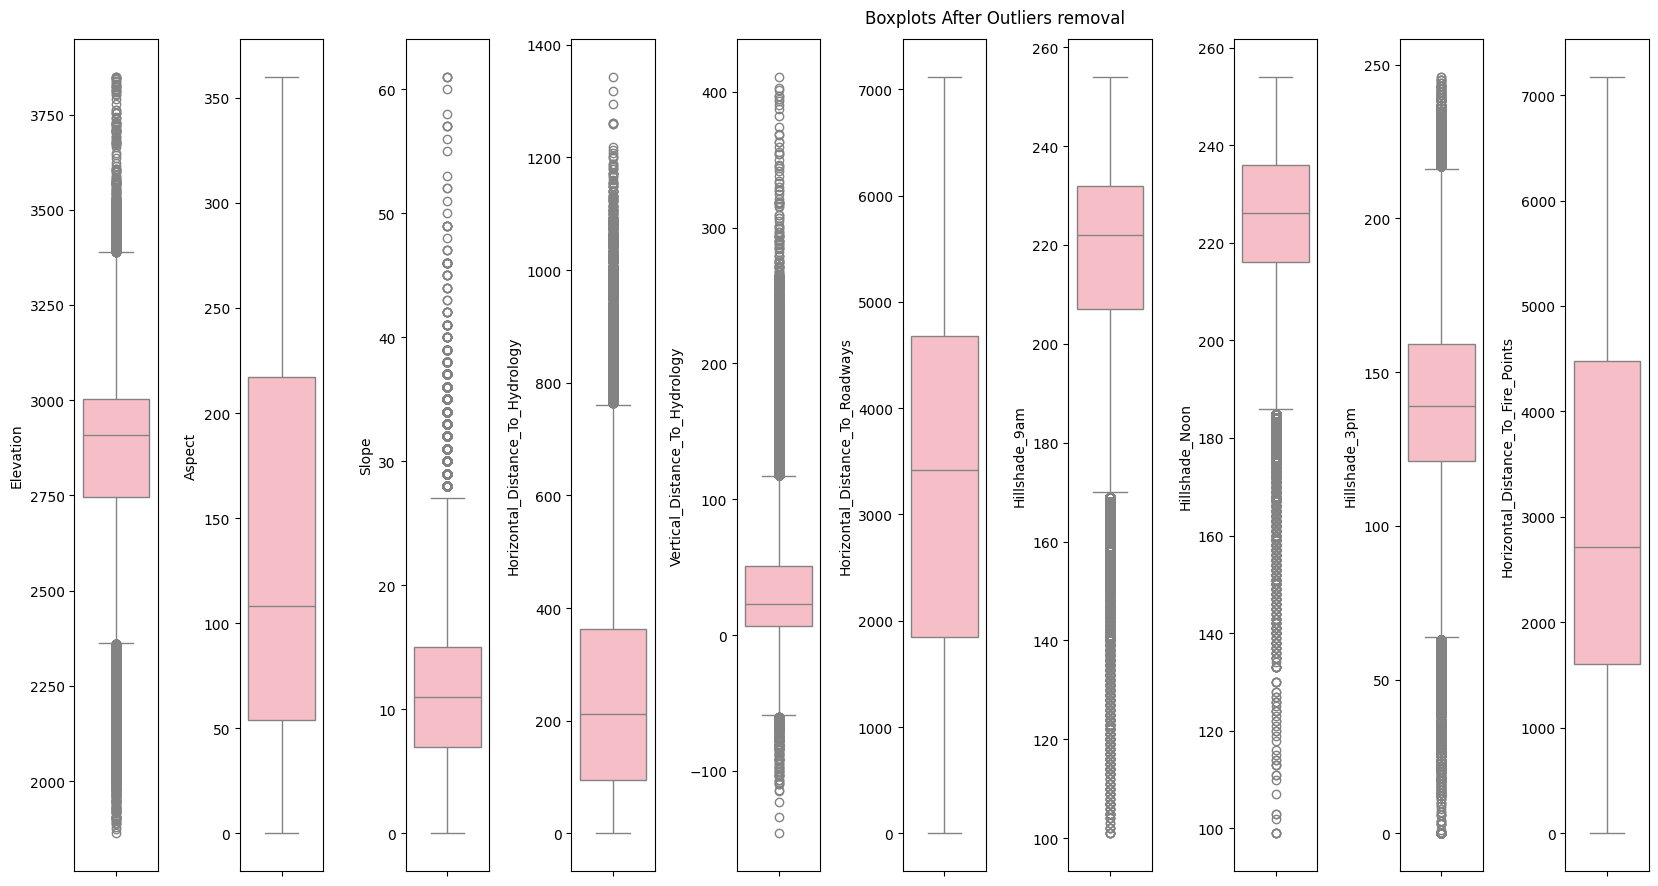

In [21]:
f_box=f.copy()
num_cols=f_box.drop(['Cover_Type','Wilderness_Area','Soil_Type'],axis=1)
num_cols=num_cols.columns
f_box=f_box.reset_index(drop=True)
plt.figure(figsize=(20, 9))
plt.suptitle("Boxplots After Outliers removal")
for i in range(0, len(num_cols)):
    plt.subplot(1, 12, i+1)
    sns.boxplot(y=f[num_cols[i]],color='lightpink')
    plt.tight_layout()


# **Feature Engineering**

In [22]:
bins = [0,45,135,225,315,360]
labels = ['North','East','South','West','North']

f['Aspect_Group'] = pd.cut(f['Aspect'],bins=bins,labels=labels,include_lowest=True,ordered=False)
f['Elevation_Slope'] = f['Elevation'] * f['Slope']


In [23]:
f["Distance_To_Hydrology"] = np.sqrt(f["Horizontal_Distance_To_Hydrology"]**2 +f["Vertical_Distance_To_Hydrology"]**2)
f["Mean_Hillshade"] = (f["Hillshade_9am"] +f["Hillshade_Noon"] +f["Hillshade_3pm"]) / 3

# **Exploratory Data Analysis**

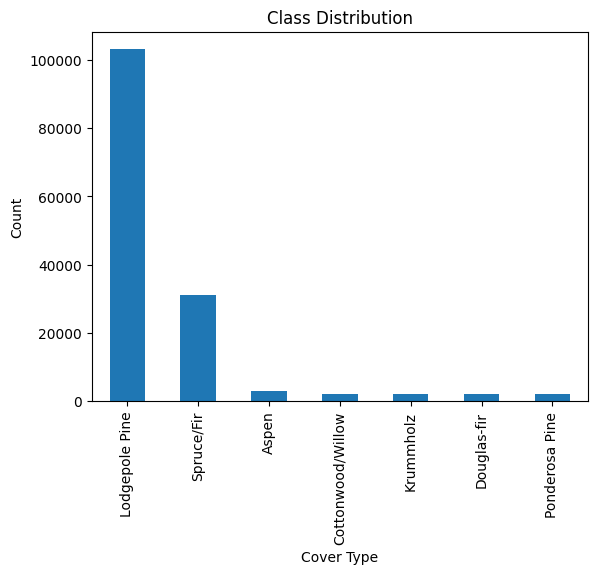

In [24]:
f["Cover_Type"].value_counts().plot(kind="bar")
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

numeric_features = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

f[numeric_features].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

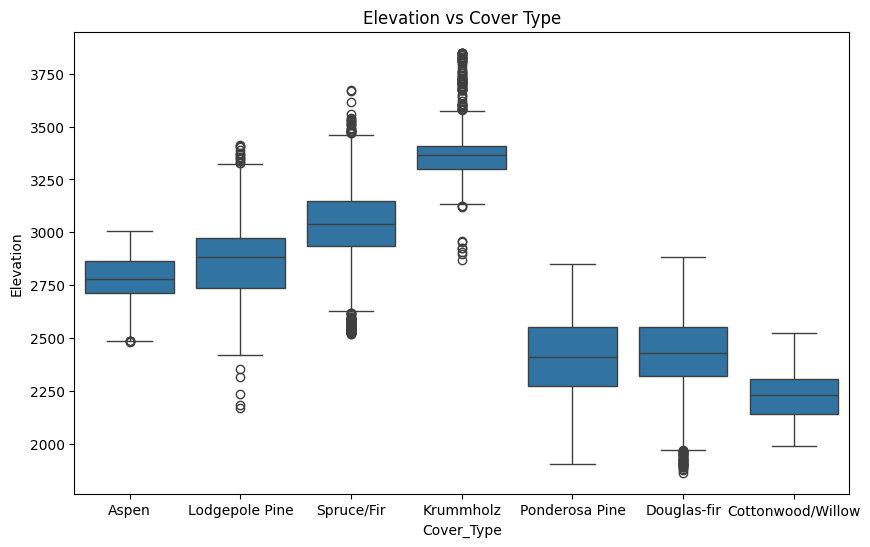

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Cover_Type",y="Elevation",data=f)
plt.title("Elevation vs Cover Type")
plt.show()

In [26]:
f['Wilderness_Area'].value_counts()

,count
Wilderness_Area,
1,134358
3,6339
4,4647
2,499


In [27]:
sample = (
  f.groupby("Cover_Type", group_keys=False)
      .apply(lambda x: x.sample(n=min(len(x), 500), random_state=42))
      .reset_index(drop=True)
)

/tmp/ipykernel_1035/3382266490.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 500), random_state=42))


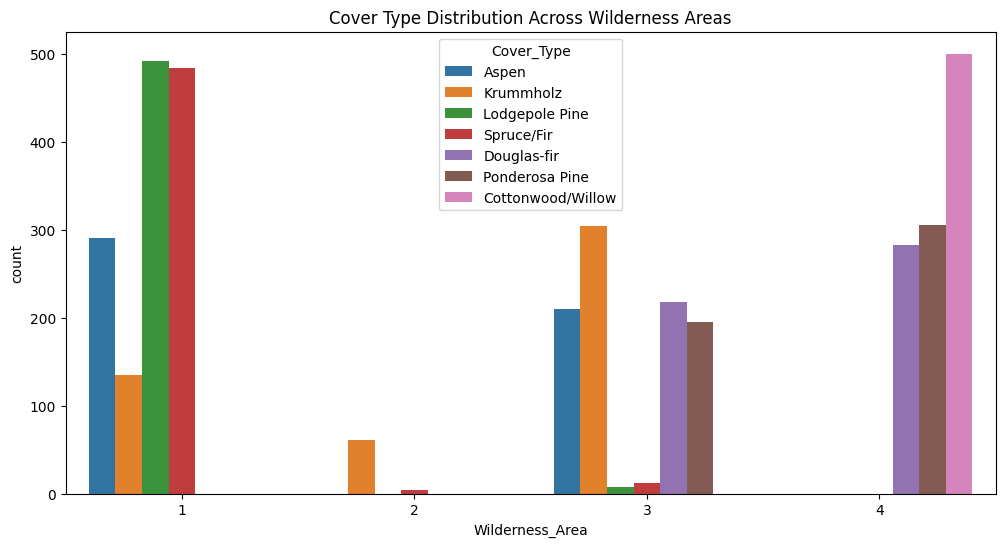

In [28]:
plt.figure(figsize=(12,6))
sns.countplot(x="Wilderness_Area",hue="Cover_Type",data=sample)
plt.title("Cover Type Distribution Across Wilderness Areas")
plt.show()

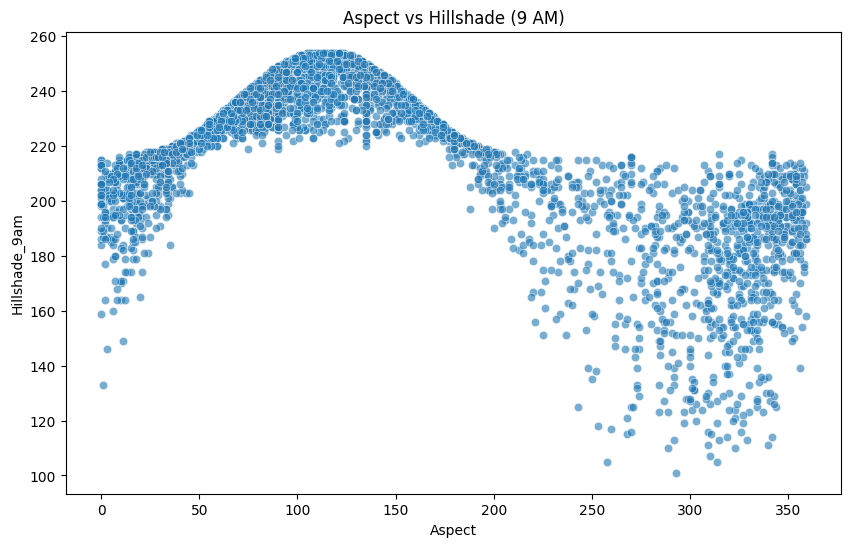

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=sample,x="Aspect",y="Hillshade_9am",alpha=0.6)
plt.title("Aspect vs Hillshade (9 AM)")
plt.show()

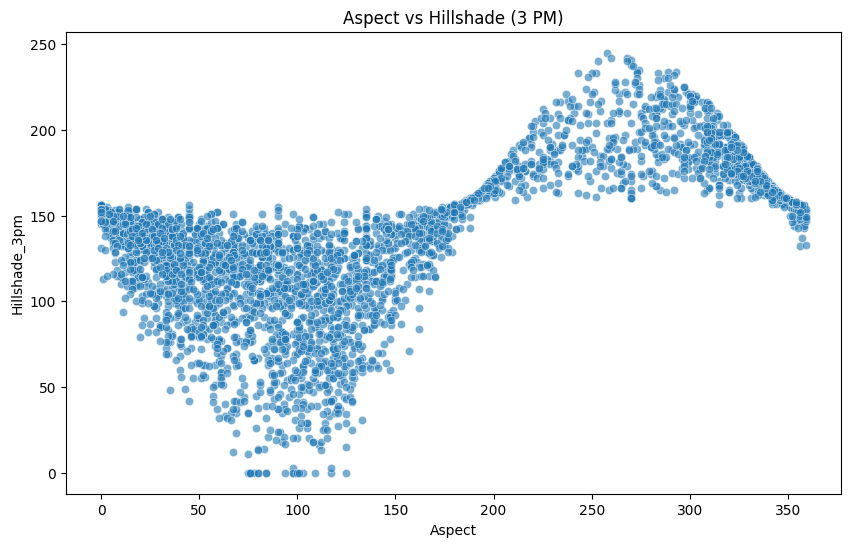

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=sample,x="Aspect",y="Hillshade_3pm",alpha=0.6)
plt.title("Aspect vs Hillshade (3 PM)")
plt.show()

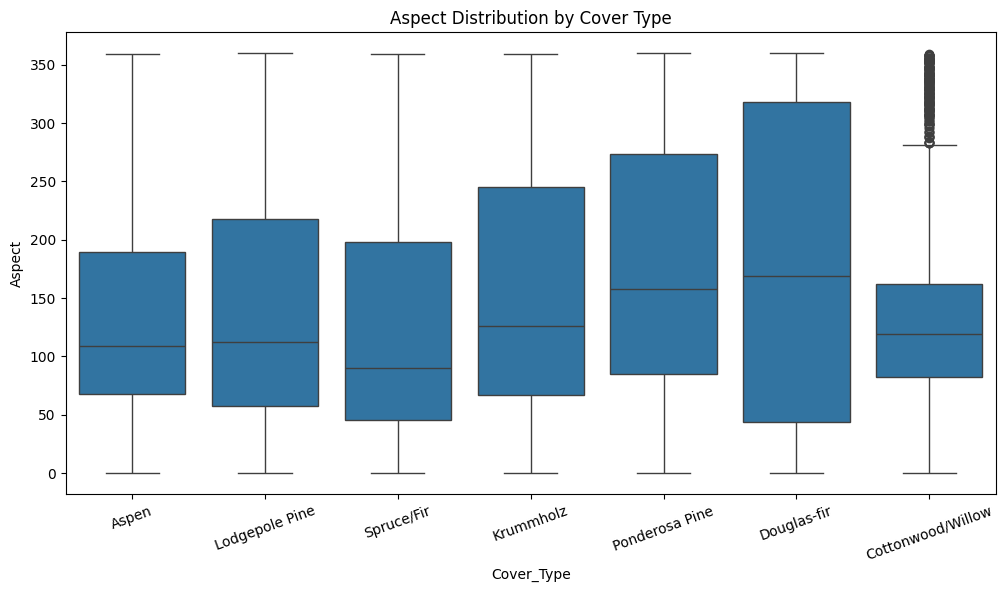

In [32]:
plt.figure(figsize=(12,6))
sns.boxplot(data=f,x="Cover_Type",y="Aspect")
plt.title("Aspect Distribution by Cover Type")
plt.xticks(rotation=20)
plt.show()

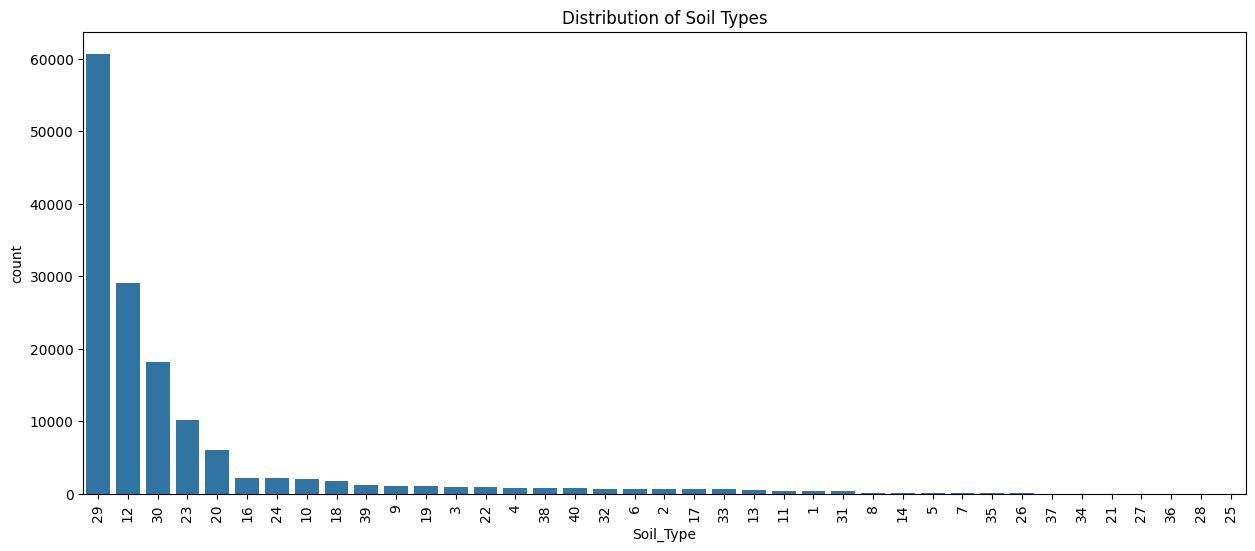

In [33]:
plt.figure(figsize=(15,6))
sns.countplot(data=f,x="Soil_Type",order=f["Soil_Type"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Distribution of Soil Types")
plt.show()

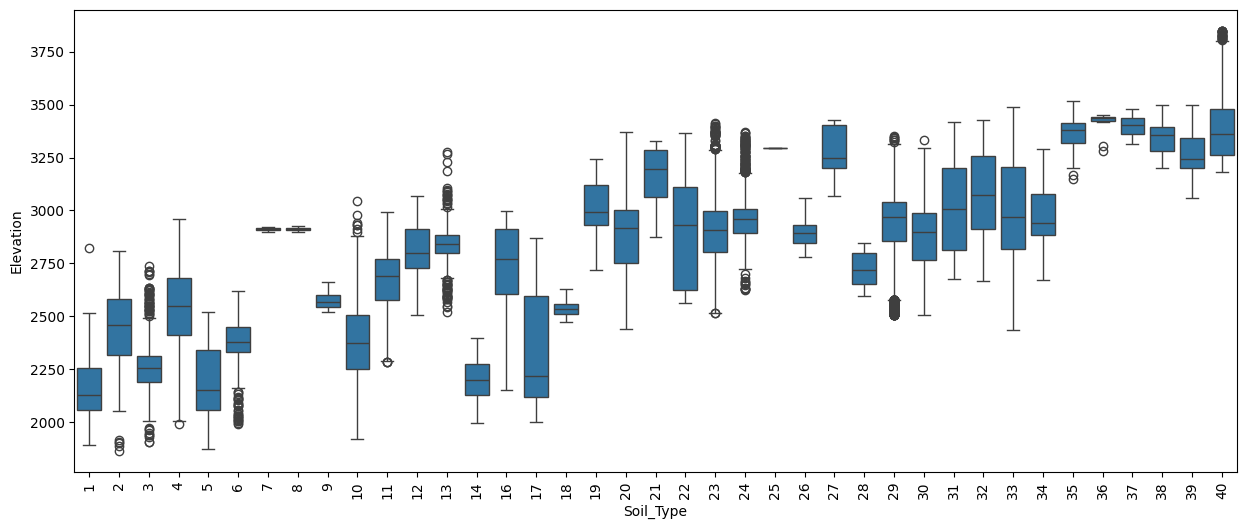

In [34]:
plt.figure(figsize=(15,6))
sns.boxplot(data=f,x="Soil_Type",y="Elevation")
plt.xticks(rotation=90)
plt.show()

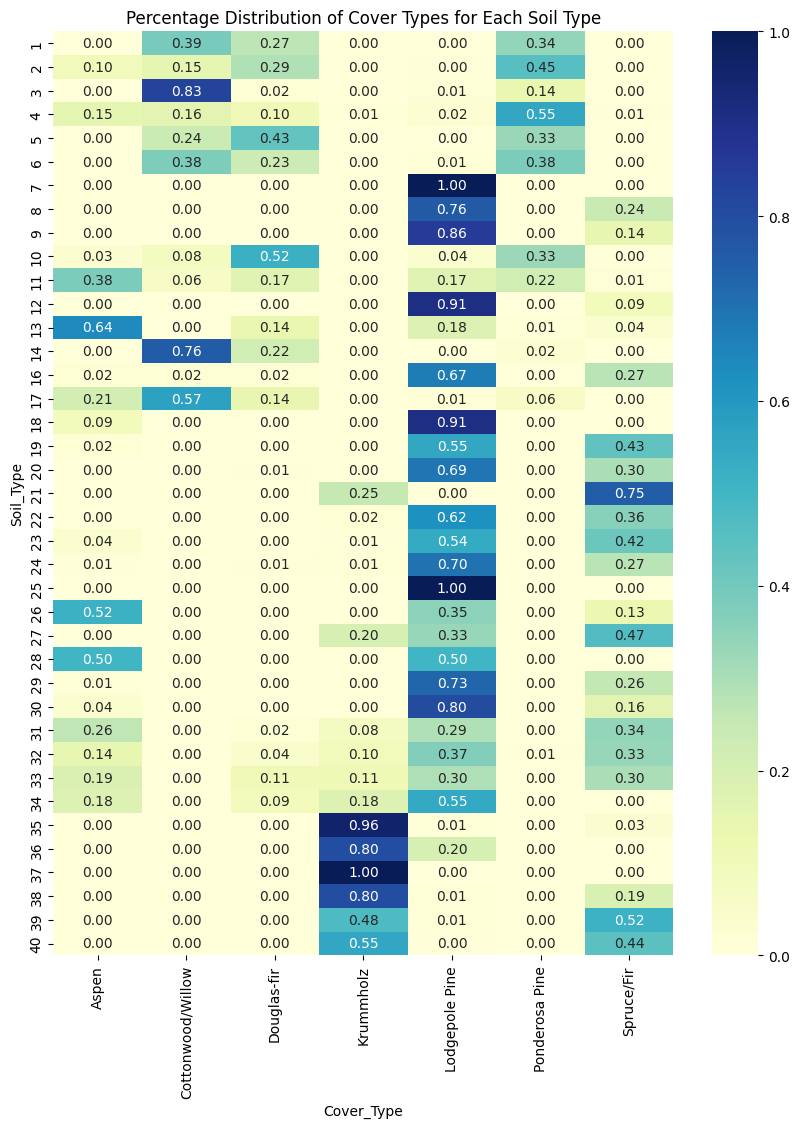

In [35]:
table = pd.crosstab(f["Soil_Type"],f["Cover_Type"],normalize="index")
plt.figure(figsize=(10,12))
sns.heatmap(table,annot=True,cmap="YlGnBu",fmt=".2f")
plt.title("Percentage Distribution of Cover Types for Each Soil Type")
plt.show()

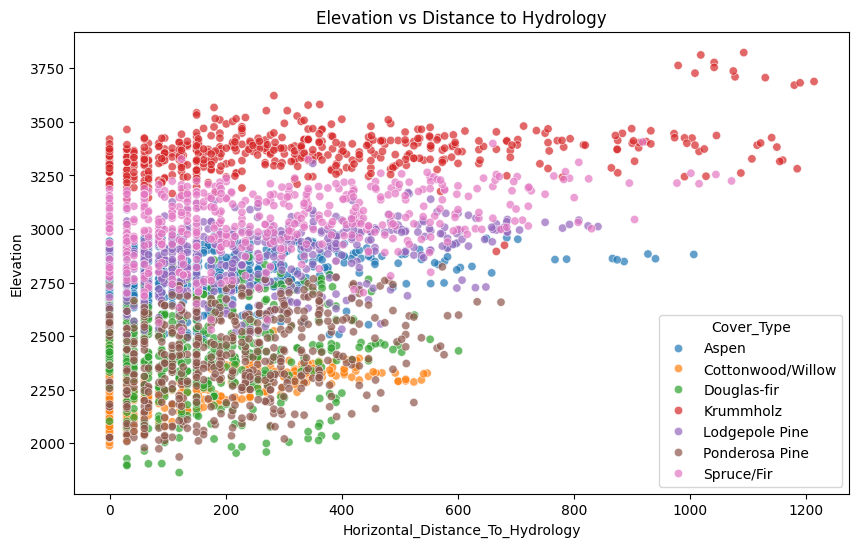

In [36]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=sample,x="Horizontal_Distance_To_Hydrology",y="Elevation",hue="Cover_Type",alpha=0.7)
plt.title("Elevation vs Distance to Hydrology")
plt.show()

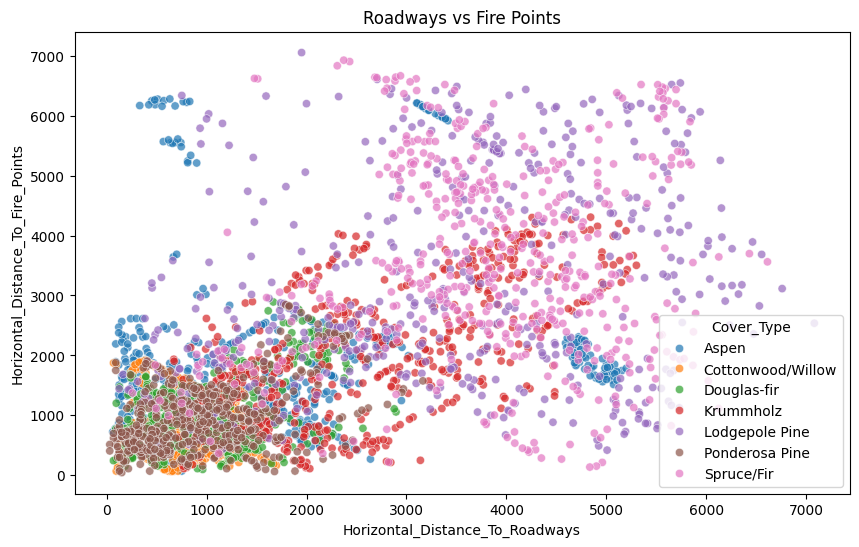

In [38]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=sample,x="Horizontal_Distance_To_Roadways",y="Horizontal_Distance_To_Fire_Points",hue="Cover_Type",alpha=0.7)
plt.title("Roadways vs Fire Points")
plt.show()

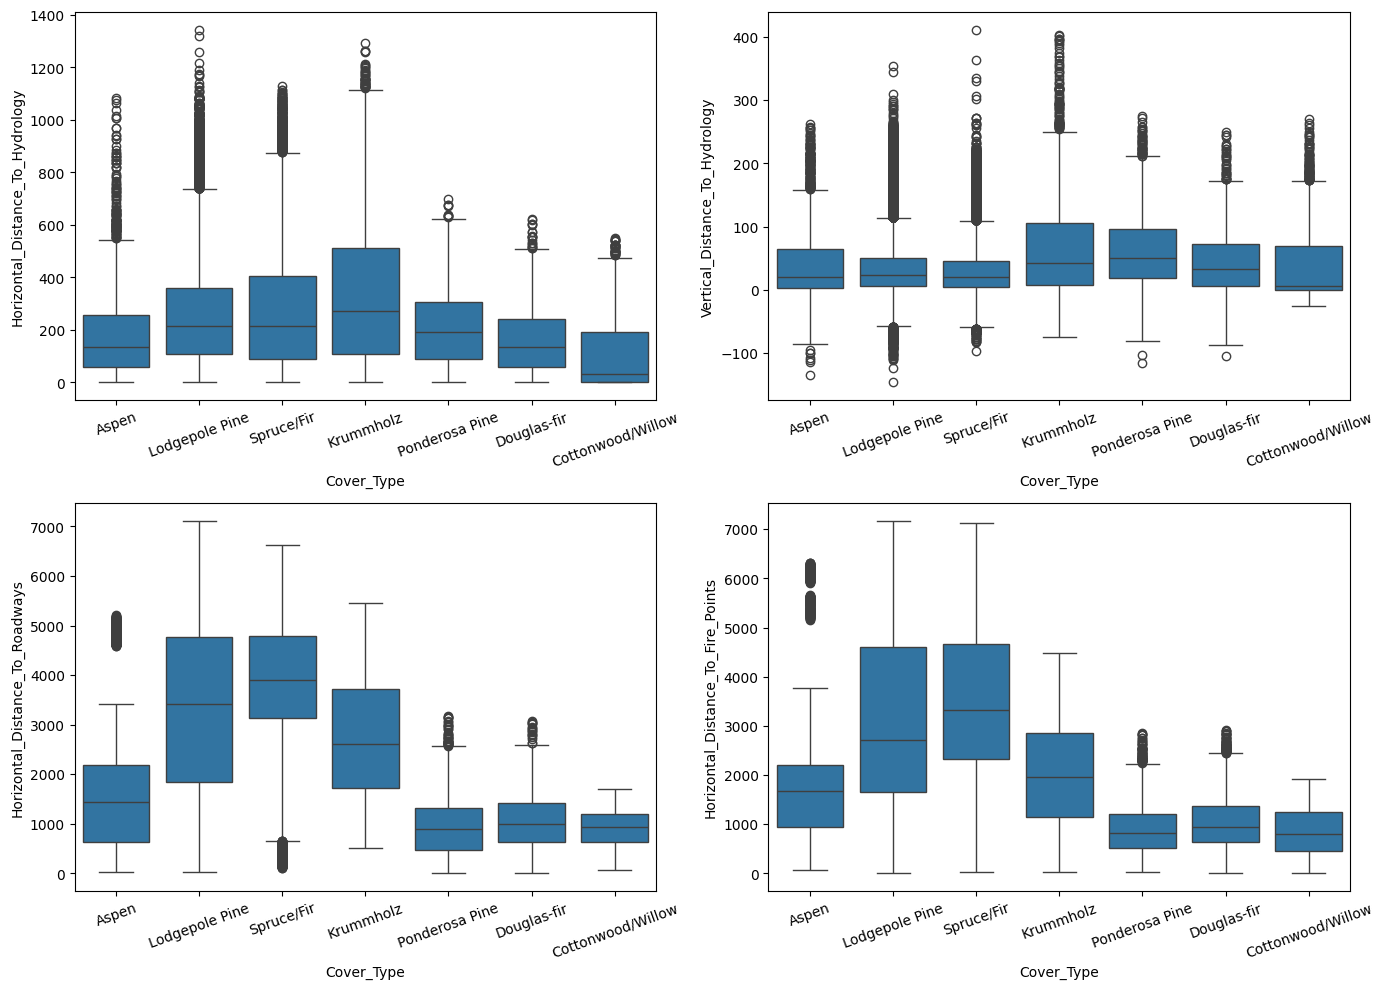

In [40]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

cols = [
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Horizontal_Distance_To_Fire_Points"
]

for ax, col in zip(axes.flat, cols):
    sns.boxplot(
        data=f,
        x="Cover_Type",
        y=col,
        ax=ax
    )
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# **Handling Skewness**

In [41]:
f.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Aspect_Group,Elevation_Slope,Distance_To_Hydrology,Mean_Hillshade
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29,East,7788,258.000000,200.333333
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29,East,5180,212.084889,202.000000
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12,South,25236,275.769832,202.333333
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30,South,50130,269.235956,199.333333
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29,North,5190,153.003268,201.333333


In [42]:
skewness=f[num_cols].skew()
print(skewness)

Elevation                            -0.661066
Aspect                                0.690413
Slope                                 0.928725
Horizontal_Distance_To_Hydrology      0.984665
Vertical_Distance_To_Hydrology        1.761357
Horizontal_Distance_To_Roadways      -0.058507
Hillshade_9am                        -1.240752
Hillshade_Noon                       -0.943221
Hillshade_3pm                        -0.170903
Horizontal_Distance_To_Fire_Points    0.365056
dtype: float64


Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Hillshade_9am', 'Hillshade_Noon'],
      dtype='object')


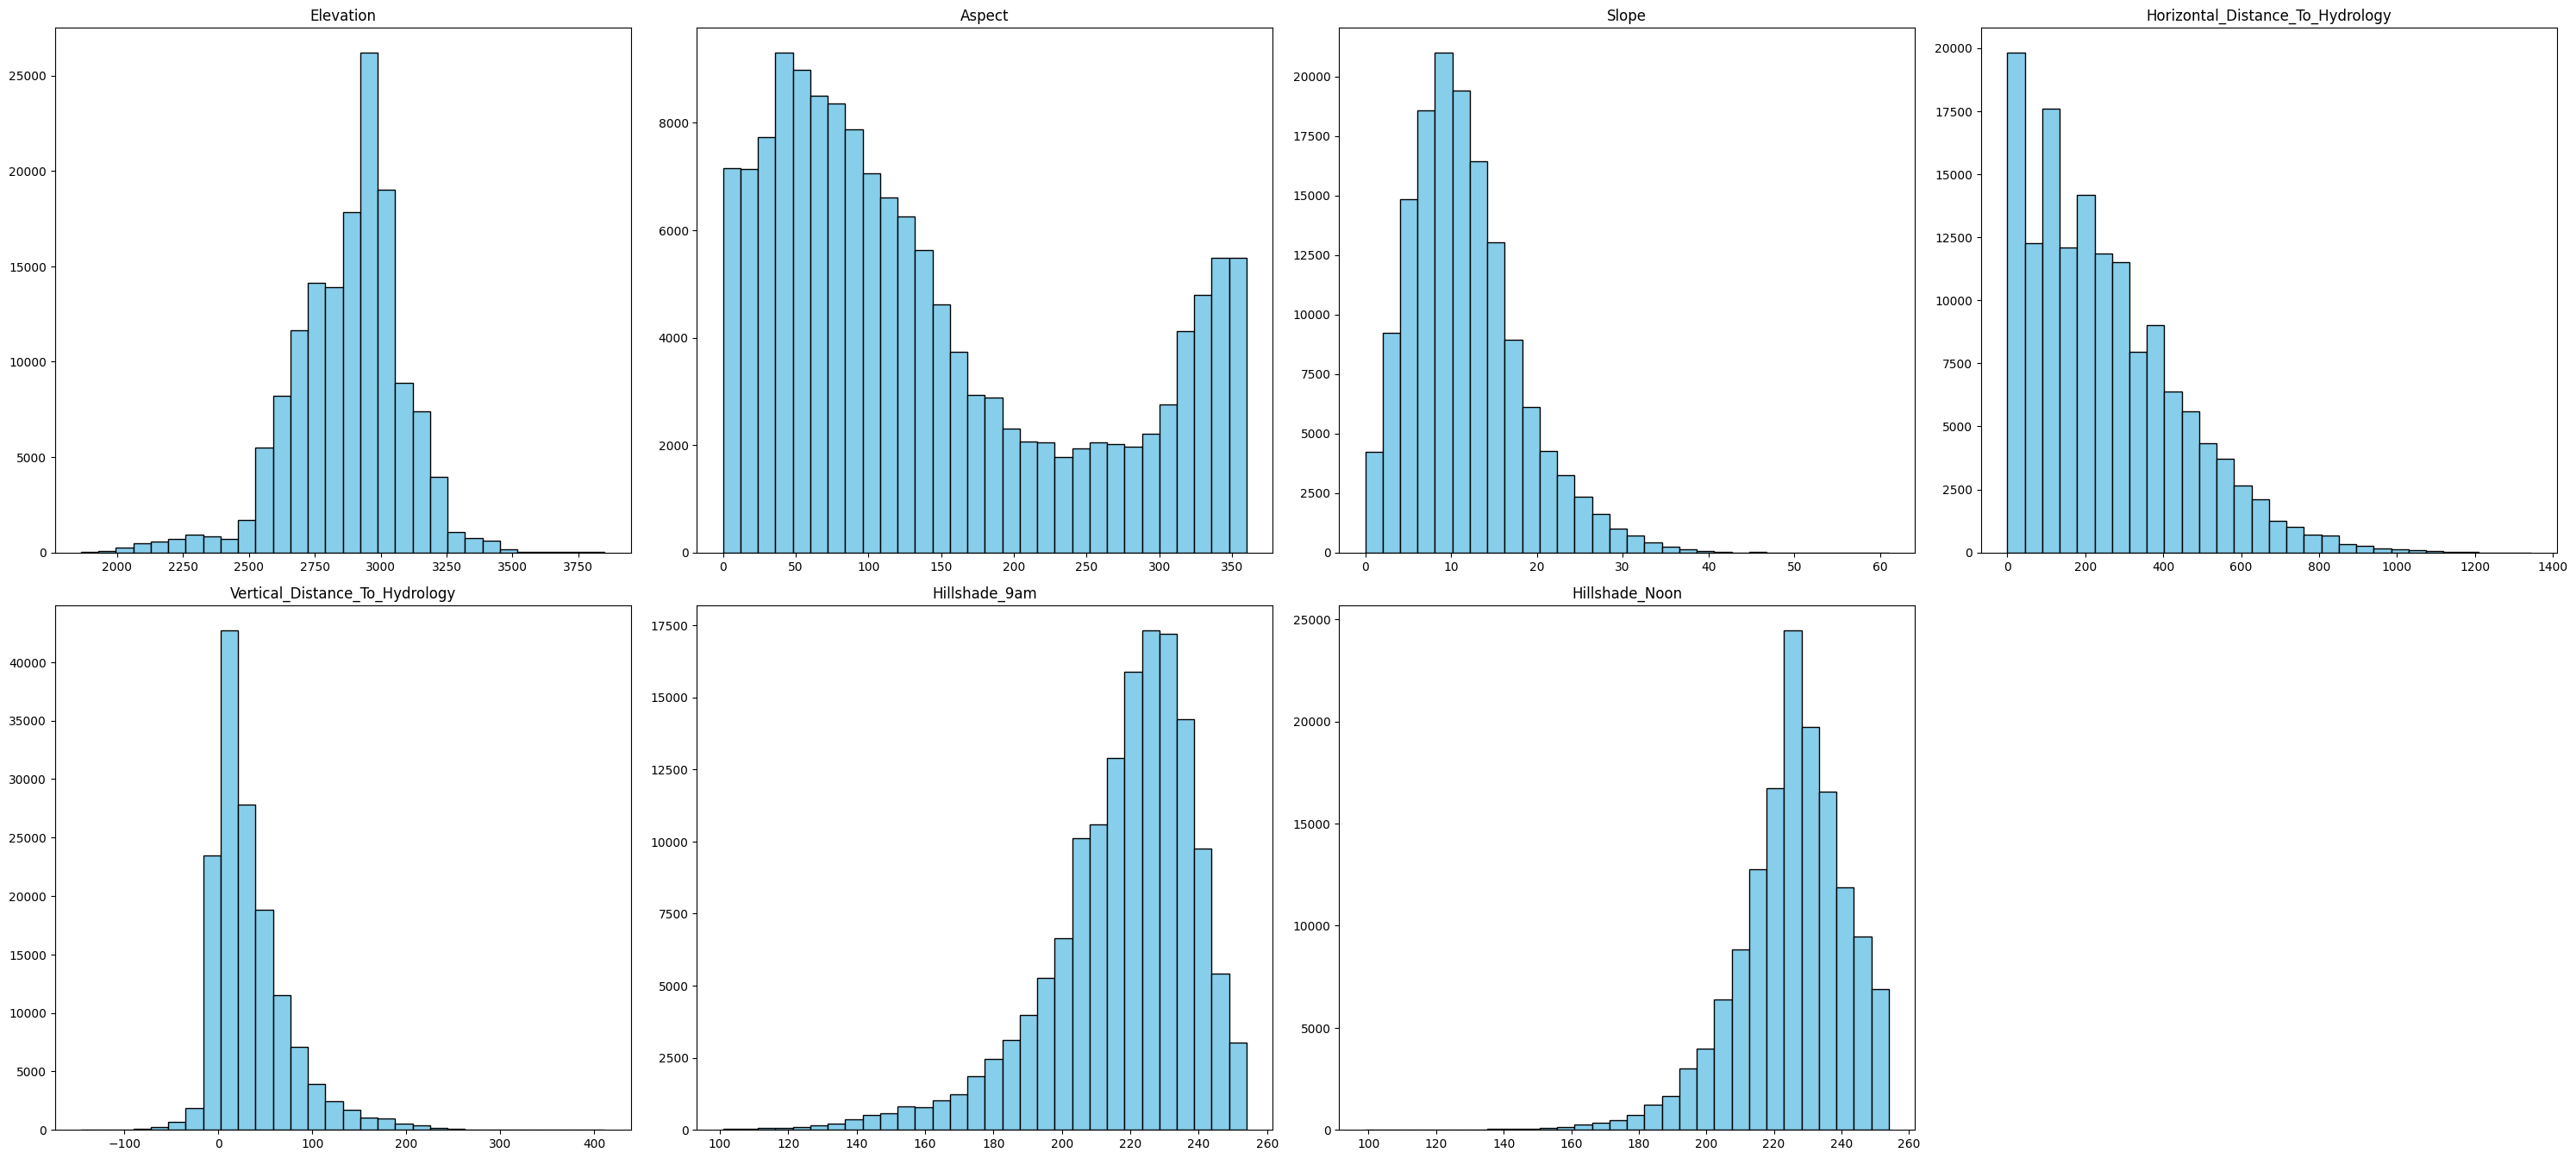

In [43]:
# Select numerical columns with high skewness (absolute skewness > 0.5)
skewed_cols = skewness[abs(skewness) > 0.5].index
print(skewed_cols)
# Plot histograms before transformation
plt.figure(figsize=(30, 20))
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(3, 4, i)  # Adjust grid size as needed
    plt.hist(f[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

In [44]:

# log transformation
f["Slope"] = np.log1p(f["Slope"])
# Yeo-Johnson transformation
pt = PowerTransformer(method="yeo-johnson")
f[["Vertical_Distance_To_Hydrology"]] = pt.fit_transform(f[["Vertical_Distance_To_Hydrology"]])
f[["Hillshade_9am"]] = pt.fit_transform(f[["Hillshade_9am"]])
f[["Hillshade_Noon"]] = pt.fit_transform(f[["Hillshade_Noon"]])

In [45]:
f[num_cols].skew()

,0
Elevation,-0.661066
Aspect,0.690413
Slope,-0.698791
Horizontal_Distance_To_Hydrology,0.984665
Vertical_Distance_To_Hydrology,0.300188
Horizontal_Distance_To_Roadways,-0.058507
Hillshade_9am,-0.106806
Hillshade_Noon,-0.026707
Hillshade_3pm,-0.170903
Horizontal_Distance_To_Fire_Points,0.365056


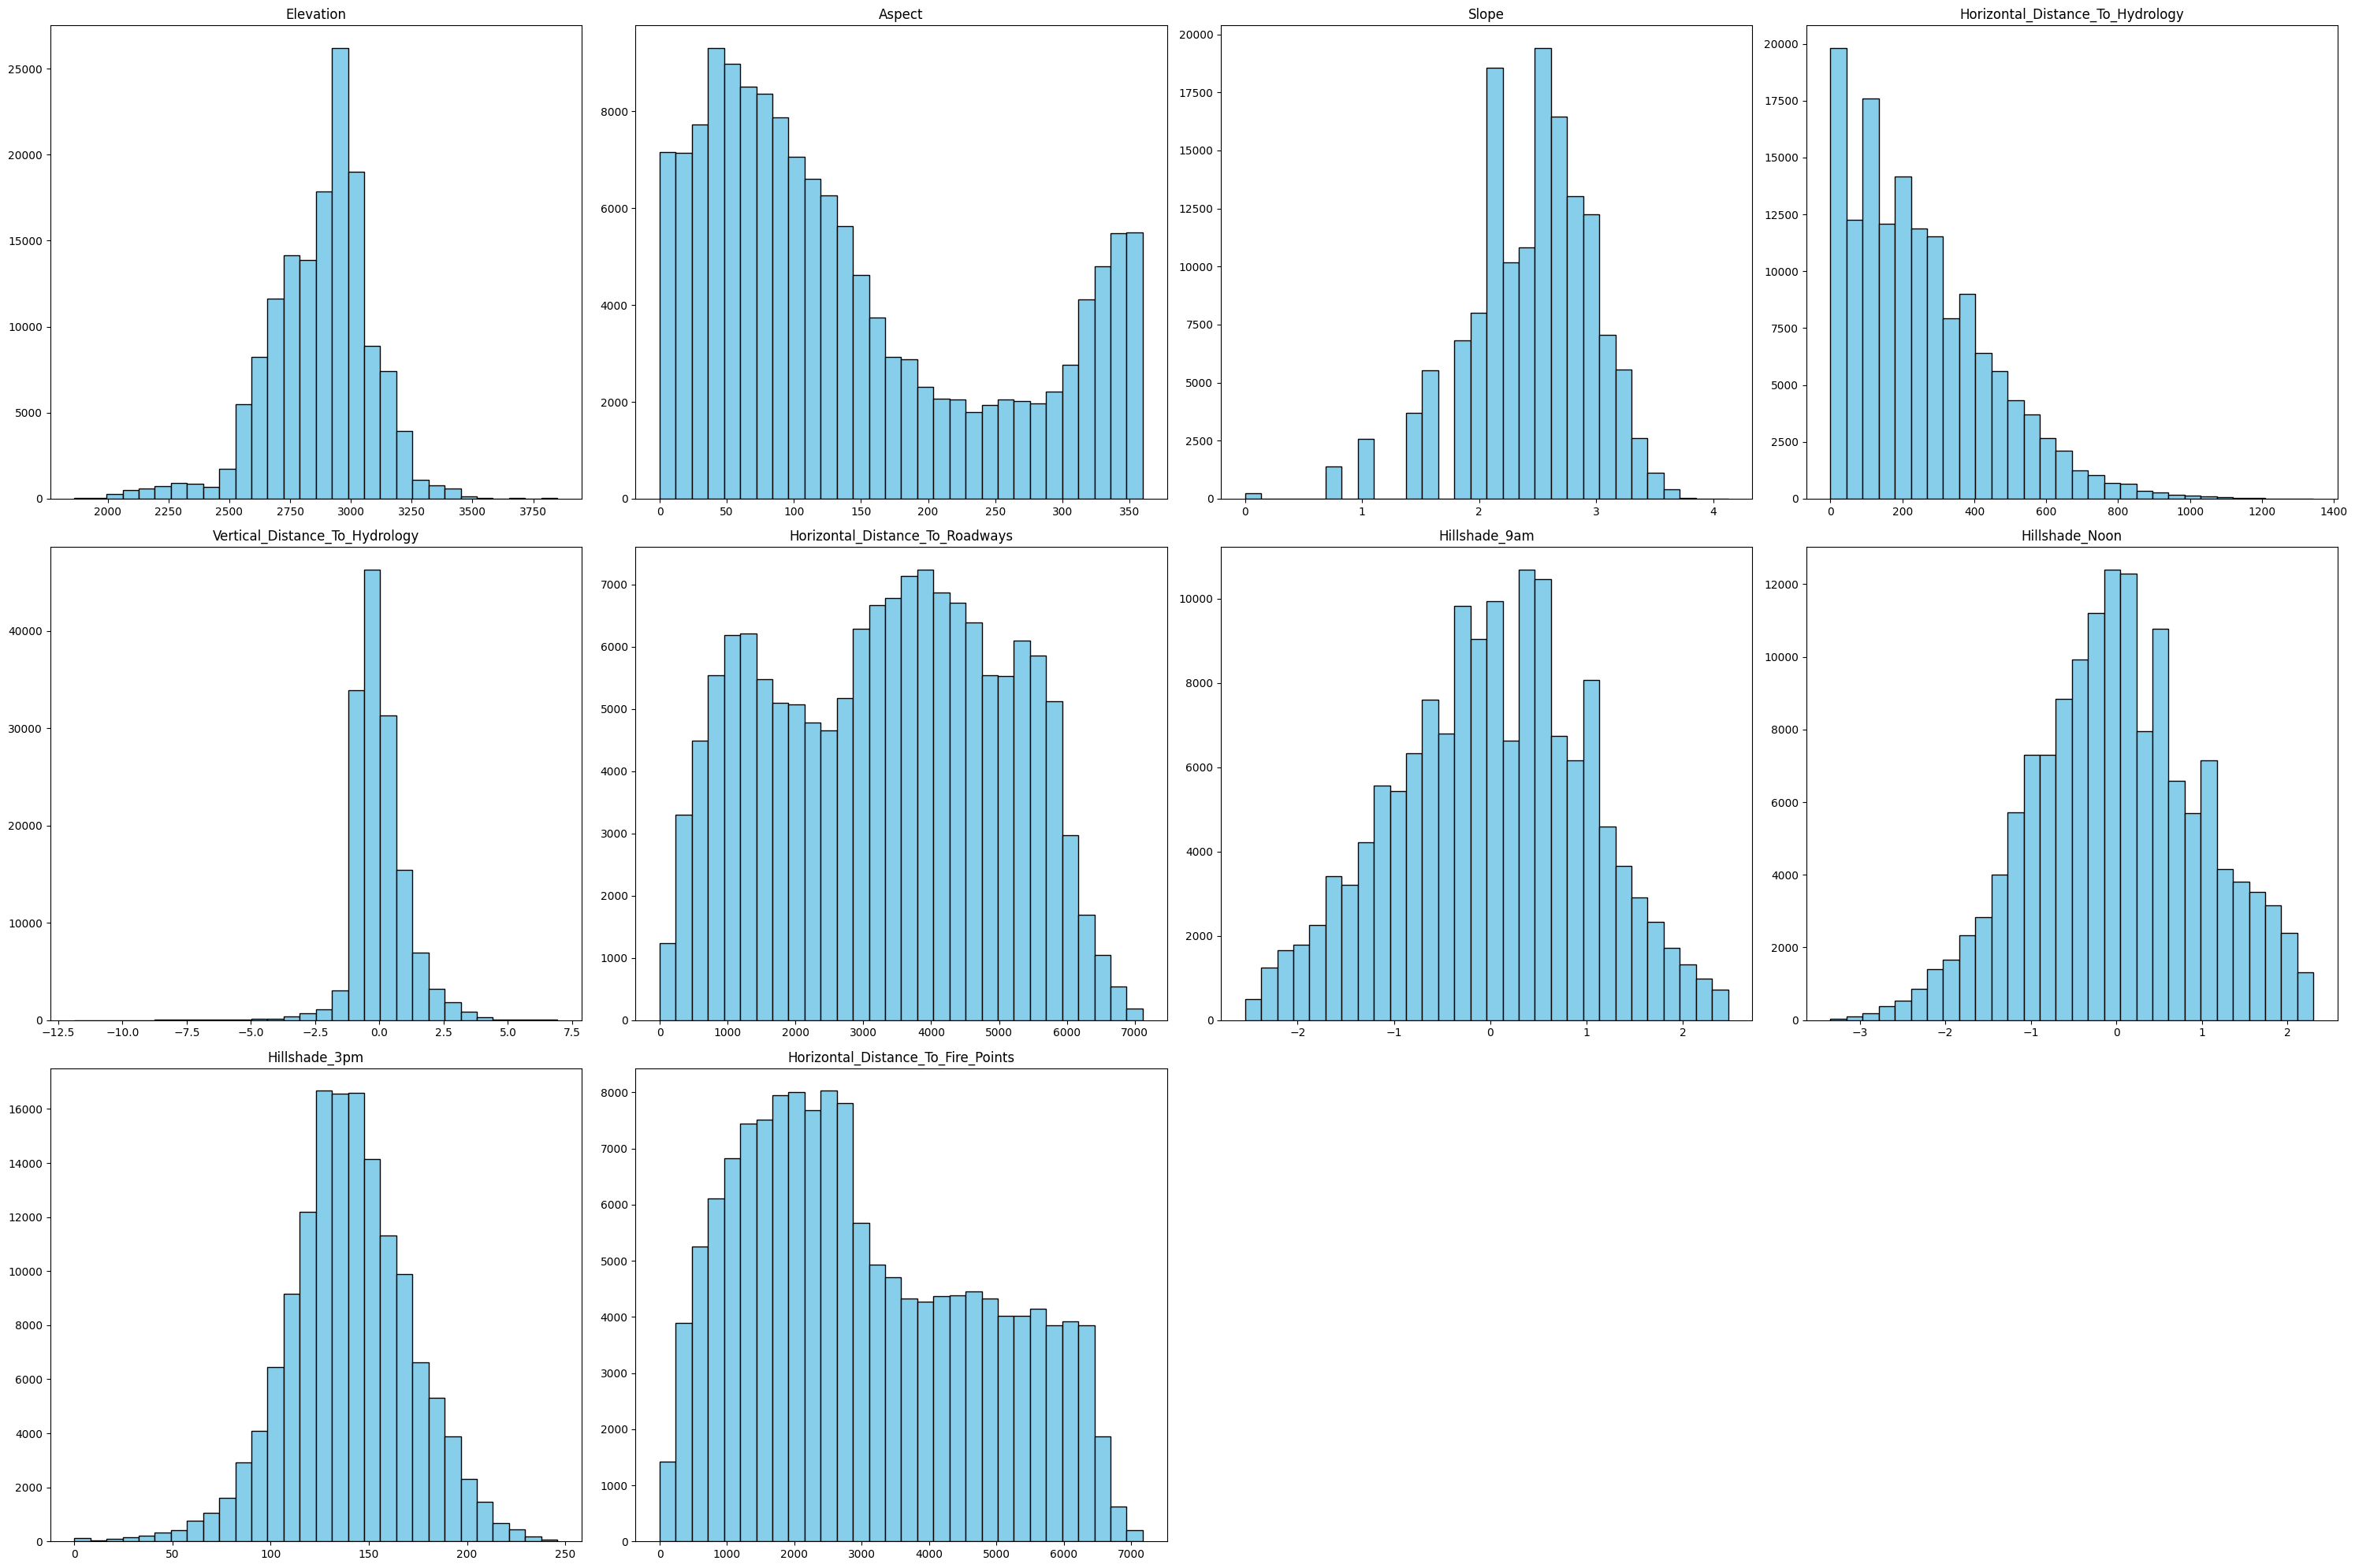

In [46]:
plt.figure(figsize=(30, 20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 4, i)  # Adjust grid size as needed
    plt.hist(f[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

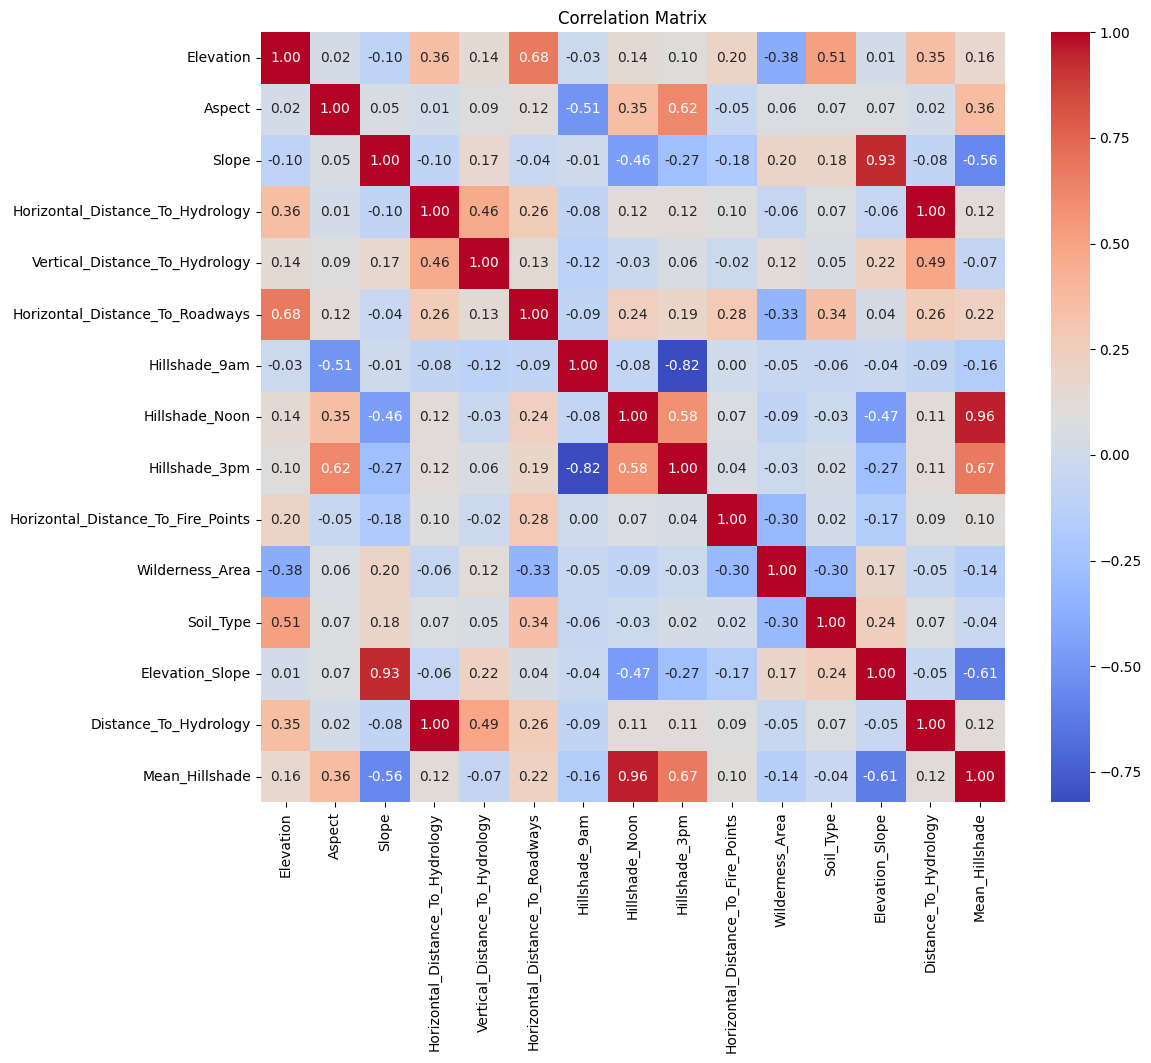

In [47]:
plt.figure(figsize=(12,10))
num_col = f.select_dtypes(include='number').columns.tolist()
sns.heatmap(
    f[num_col].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# **Label Encoder**

In [48]:

cover_encoder = LabelEncoder()

f["Cover_Type"] = cover_encoder.fit_transform(f["Cover_Type"])
print(cover_encoder.classes_)
with open("Cover_Type.pkl", "wb") as file:
  pickle.dump(cover_encoder, file)
aspect_encoder = LabelEncoder()
f['Aspect_Group']=aspect_encoder.fit_transform(f['Aspect_Group'])


['Aspen' 'Cottonwood/Willow' 'Douglas-fir' 'Krummholz' 'Lodgepole Pine'
 'Ponderosa Pine' 'Spruce/Fir']


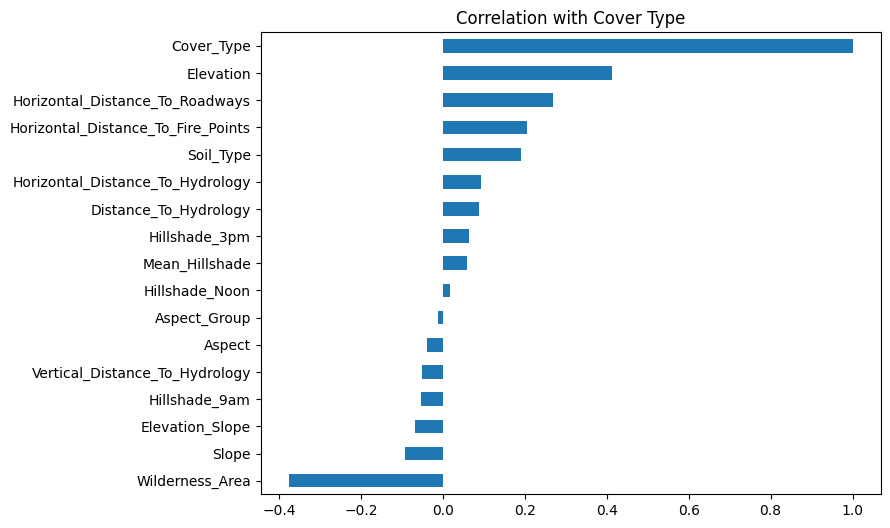

In [49]:
corr = f.corr(numeric_only=True)["Cover_Type"].sort_values()

plt.figure(figsize=(8,6))

corr.plot(kind="barh")

plt.title("Correlation with Cover Type")

plt.show()

# **Feature Selection**

In [50]:


X = f.drop(columns=['Cover_Type'])
y = f['Cover_Type']

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top features
feature_importance_df


,Feature,Importance
0,Elevation,0.256250
5,Horizontal_Distance_To_Roadways,0.140787
9,Horizontal_Distance_To_Fire_Points,0.128395
11,Soil_Type,0.084288
10,Wilderness_Area,0.072647
14,Distance_To_Hydrology,0.046418
4,Vertical_Distance_To_Hydrology,0.045670
3,Horizontal_Distance_To_Hydrology,0.037063
1,Aspect,0.032533
6,Hillshade_9am,0.028866


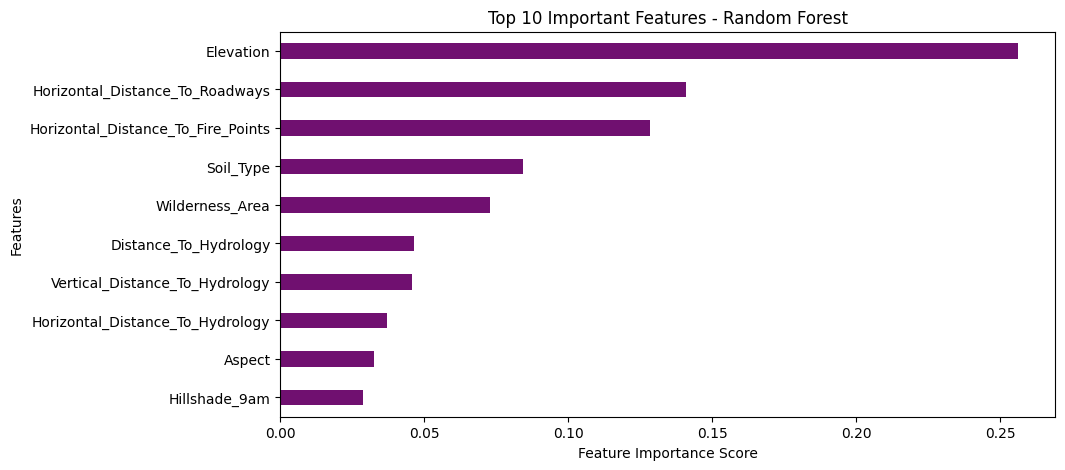

In [51]:
plt.figure(figsize=(10,5))
sns.barplot(x=feature_importance_df['Importance'][:10], y=feature_importance_df['Feature'][:10], color='purple', width=0.4)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")
plt.show()

In [52]:
top=['Elevation','Horizontal_Distance_To_Roadways','Horizontal_Distance_To_Fire_Points','Soil_Type','Wilderness_Area','Distance_To_Hydrology','Aspect','Mean_Hillshade','Cover_Type']
data=f[top]

# **Model Building**

In [75]:
import warnings
import numpy as np
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [54]:
# Define features (X) and target (y)
X = f.drop('Cover_Type', axis=1)
y = f['Cover_Type']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# **Handling Class Imbalance**

In [56]:
categorical_cols = ['Wilderness_Area', 'Soil_Type']

# SMOTE needs categorical columns as indices for non-continuous features
categorical_indices = [X.columns.get_loc(col) for col in categorical_cols]

# Apply SMOTE
smote = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Convert to DataFrame
df_resampled = pd.DataFrame(X_train, columns=X.columns)
df_resampled['Cover_Type'] = y_train

# Verify the new class distribution
df_resampled['Cover_Type'].value_counts()

,count
Cover_Type,
4,82448
6,82448
1,82448
5,82448
0,82448
3,82448
2,82448


In [57]:
y_train.info()

<class 'pandas.core.series.Series'>
RangeIndex: 577136 entries, 0 to 577135
Series name: Cover_Type
Non-Null Count   Dtype
--------------   -----
577136 non-null  int64
dtypes: int64(1)
memory usage: 4.4 MB


In [58]:
scale_cols = [
    'Elevation',
    'Horizontal_Distance_To_Roadways',
    'Horizontal_Distance_To_Fire_Points',
    'Distance_To_Hydrology',
    'Aspect',
    'Mean_Hillshade'
]

In [59]:
scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])
with open("scaler.pkl", "wb") as file:
  pickle.dump(scaler, file)

In [60]:
X_train.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Aspect_Group,Elevation_Slope,Distance_To_Hydrology,Mean_Hillshade
0,0.118859,-0.776316,2.197225,30,-0.917598,0.274678,-0.560933,-0.187295,151,0.705607,1,23,1,22416,-0.631575,0.131106
1,-0.115689,-0.342105,2.708050,361,0.161351,-0.299142,0.965895,-0.848469,105,-0.327687,1,29,0,37156,0.762113,-0.432531
2,0.470681,1.401316,1.386294,90,-0.430458,0.528326,-0.368030,0.599637,160,2.804322,1,29,1,9072,-0.376696,0.567469
3,0.329635,-0.539474,2.397895,95,-0.457545,0.978970,0.060874,-0.562530,130,-0.028621,1,29,1,29350,-0.356508,-0.141622
4,0.169572,-0.171053,2.302585,0,-0.828249,1.819313,0.894153,0.083478,123,1.843458,1,30,0,25506,-0.757478,0.149287


# **Baseline model**

In [61]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import f1_score
print("Macro F1:",f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.9526209331824883
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       614
           1       0.93      0.95      0.94       432
           2       0.78      0.82      0.80       431
           3       0.90      0.97      0.93       432
           4       0.98      0.96      0.97     20613
           5       0.79      0.79      0.79       426
           6       0.91      0.93      0.92      6221

    accuracy                           0.95     29169
   macro avg       0.87      0.91      0.89     29169
weighted avg       0.95      0.95      0.95     29169

Macro F1: 0.8873761022551808


# **Model Building**

In [62]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42,n_estimators=100),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=3000,random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42,eval_metric='mlogloss')
}


results = {}
predictions = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Store predictions
    predictions[name] = y_pred
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test,y_pred,average='macro')
    weighted_f1 = f1_score(y_test,y_pred,average='weighted')
    # Store results
    results[name] = {'Accuracy': accuracy,'Macro F1': macro_f1,'Weighted F1': weighted_f1}

# Convert results to table
results_df = pd.DataFrame(results).T

# Round values
results_df = results_df.round(4)

# Display table
print("\n📊 Model Performance:")
print(results_df)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



📊 Model Performance:
                     Accuracy  Macro F1  Weighted F1
Random Forest          0.9526    0.8874       0.9531
Decision Tree          0.9295    0.8483       0.9305
Logistic Regression    0.3041    0.2618       0.3741
KNN                    0.3971    0.2249       0.4714
XGBoost                0.9079    0.8569       0.9082


**Cross Validation**

In [63]:

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=stratified_kfold, scoring='accuracy')
    # Store mean accuracy
    model_results[name] = scores.mean()
    print(f"{name}: Mean Accuracy = {scores.mean():.4f}")

Random Forest: Mean Accuracy = 0.9882
Decision Tree: Mean Accuracy = 0.9709


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression: Mean Accuracy = 0.4572
KNN: Mean Accuracy = 0.7282
XGBoost: Mean Accuracy = 0.9706


In [64]:
best_model_name = results_df['Macro F1'].idxmax()

print("Best Model:", best_model_name)
print("Best Macro F1:", results_df.loc[best_model_name, 'Macro F1'])

Best Model: Random Forest
Best Macro F1: 0.8874


In [65]:
best_model = models[best_model_name]

print(best_model)

RandomForestClassifier(random_state=42)


**Hyperparameter Tuning**

In [66]:


# Base Random Forest
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Smaller parameter space
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train only on training data
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)

# Best model
best_rf = random_search.best_estimator_

# Predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

# Macro F1
train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Train Macro F1:", train_f1)
print("Test Macro F1:", test_f1)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best CV Accuracy:
0.9855822595013034

Train Accuracy: 1.0
Test Accuracy: 0.9528951969556722
Train Macro F1: 1.0
Test Macro F1: 0.8897261197708508


In [67]:
best_rf = random_search.best_estimator_

y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

Train Accuracy: 1.0000
Test Accuracy: 0.9529


In [68]:
with open("best_model.pkl", "wb") as file:
    pickle.dump(best_rf, file)